# PID loop simulator
## Run a closed loop PID simulator to allow testing different options.
## This version extracts the open loop reproduction of data from a night to use for testing.
Craig Lage 16-Apr-26

In [1]:
import numpy as np
import pickle as pkl
import pandas as pd
import galsim
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from lsst.ts.ofc import OFC, OFCData, StateEstimator, SensitivityMatrix

## The cell below sets up the simulation options

In [73]:
# Where to get the data
day_obs = 20260329
seq_start = 4
seq_end = 200

# Correction options
N_correct = 3 # What we call correction lag
discard_intermediates = True
control_vmodes = True

# PID loop values
# These must be arrays of length 50.
# This can probably be simplified.
# If control_vmodes = True, then the _used values should have 12
# components.  Otherwise, if control_vmodes = False, they should have 22 components
# Indices just collapses the 50 DOF down to the 22 we are using
indices = list(range(0, 17)) + list(range(30,35)) 

"""

# This is a starting point for control_vmodes = False
Kp = np.zeros(50)
Kp_used = 0.3 * np.ones(22)
Kp[indices] = Kp_used
Ki = np.zeros(50)
Ki_used = 0.0 * np.ones(22)
Ki[indices] = Ki_used
Kd =np.zeros(50)

"""

# This is a starting point for control_vmodes = True
Kp = np.zeros(50)
Kp_used = np.array([0.3, 0.3, 0.3, 0.3, 0.3, 0.05, 0.05, 0.3, 0.3, 0.3, 0.3, 0.3])
Kp[0:12] = Kp_used
Ki = np.zeros(50)
Ki_used = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
Ki[0:12] = Ki_used
Kd =np.zeros(50)


# Integral mode. This is the max value the PID integral can have

max_integral = np.zeros(50)
max_integral_used = 5000.0 * np.ones(22)
max_integral[indices] = max_integral_used


## The cell below gets data that allows testing.  This is how we initiate the PID simulation.
## THIS PARQUET TABLE MUST BE EXTRACTED AT THE SUMMIT!! USDF SOFTWARE IS BEHIND!!

In [50]:
# Load the nightly table.
# The parquet file was created with: 
# https://github.com/lsst-sitcom/ts_aos_analysis/blob/tickets/DM-54406/notebooks/nightly_report/nightly_report_ts_version.ipynb
parquet_file = f"/home/c/cslage/u/MTAOS/times_square_reports/nightly_aos_table_{day_obs}_summit.parquet"
table = pd.read_parquet(parquet_file)
print(f'Loaded {parquet_file}: {len(table)} rows')
print(f'Columns: {sorted(table.columns.tolist())}')

Loaded /home/c/cslage/u/MTAOS/times_square_reports/nightly_aos_table_20260329_summit.parquet: 798 rows
Columns: ['air_temp', 'airmass', 'aos_fwhm', 'azimuth', 'band', 'block', 'cam_air_temp', 'cam_m1m3_delta_t', 'day_obs', 'detector', 'dimm', 'dof_state', 'dome_delta_t', 'donut_blur_fwhm', 'elevation', 'faults', 'fwhm_zenith_500nm', 'lut_state', 'm1m3_air_temp', 'm2_air_temp', 'm2_delta_t', 'obs_end', 'obs_start', 'outside_temp', 'psf_area', 'psf_area_max', 'psf_area_min', 'psf_ellipticity_median', 'psf_ellipticity_sigma', 'psf_fwhm', 'psf_fwhm_05', 'psf_fwhm_95', 'psf_fwhm_95_05', 'psf_fwhm_max', 'psf_fwhm_min', 'psf_fwhm_sigma', 'radial_gradient', 'rotation_angle', 'seq', 'seq_num_corr', 'time', 'visit_id', 'vmodes', 'x_gradient', 'y_gradient', 'z10', 'z11', 'z12', 'z13', 'z14', 'z15', 'z16', 'z17', 'z18', 'z19', 'z22', 'z23', 'z24', 'z25', 'z26', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z_gradient', 'zernikes_191', 'zernikes_195', 'zernikes_199', 'zernikes_203', 'zernikes_fwhm', 'zk_con

## Build ofc, state estimator and sensitivity matrix

In [4]:
# You will need to git clone ts_config_mttcs and replace the location with yours.
ofc_data = OFCData(
    name="lsst",
    config_dir="/home/c/cslage/WORK/ts_config_mttcs/MTAOS/ofc" 
)

ofc = OFC(
    ofc_data=ofc_data,
)

new_comp_dof_idx = dict(
    m2HexPos=np.ones(5, dtype=bool),
    camHexPos=np.ones(5, dtype=bool),
    M1M3Bend=np.ones(20, dtype=bool),
    M2Bend=np.ones(20, dtype=bool),
)

new_comp_dof_idx["M1M3Bend"][7:] = False
new_comp_dof_idx["M2Bend"][5:] = False

new_comp_dof_idx = dict(
    m2HexPos=np.ones(5, dtype=bool),
    camHexPos=np.ones(5, dtype=bool),
    M1M3Bend=np.ones(20, dtype=bool),
    M2Bend=np.ones(20, dtype=bool),
)
new_comp_dof_idx["M1M3Bend"][7:] = False
new_comp_dof_idx["M2Bend"][5:] = False

ofc.set_truncation_index(12)
ofc_data.zn_selected = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26])
ofc.ofc_data.comp_dof_idx = new_comp_dof_idx
ofc.controller.reset_history()
ofc.state_estimator.refresh_from_ofc_data()

sensor_ids=np.array([191, 195, 199, 203])
corner_detnames = [  # extra-focal
    "R00_SW0", "R04_SW0",
    "R40_SW0", "R44_SW0",
]
field_angles_CCS = [
    ofc_data.sample_points[det] for det in corner_detnames
]

state_estimator = StateEstimator(ofc_data)
sens_mat = state_estimator.get_sensitivity_matrix(field_angles_CCS, 0.0)

## Extract the open loop reproduction from the measured zernikes and the applied trims.

In [5]:
def extractOpenLoopReproduction(table, seq_start, seq_end, sens_mat):
    z_measured = []
    z_opens = []
    seqs = []
    rots = []
    filters = []
    indices = list(range(0, 17)) + list(range(30,35)) # This just collapses the 50 DOF down to the 22 we are using
    for seqNum in range(seq_start, seq_end):
        this_table = table[table['seq'] == seqNum]
        zernikes = np.zeros([4,23])
        zernikes[0,:] = this_table['zk_deviation_R00'].values[0]
        zernikes[1,:] = this_table['zk_deviation_R04'].values[0]
        zernikes[2,:] = this_table['zk_deviation_R40'].values[0]
        zernikes[3,:] = this_table['zk_deviation_R44'].values[0]
        if np.isnan(zernikes).any():
            print(f"{seqNum} has Nans")
            continue
        z_measured.append(zernikes)
        # Now apply sensitivity matrix
        trim = this_table['dof_state'].values[0][indices]
        z_open = applyTrim(zernikes, trim, sens_mat, subtract=False)
        z_opens.append(z_open)
        seqs.append(seqNum)
        rots.append(this_table['rotation_angle'].values[0])
        filters.append(this_table['band'].values[0].split('_')[0])
    return [seqs, z_measured, z_opens, rots, filters]

## Define the subroutines to run the PID loop

In [6]:
def applyTrim(zernikes, trim, sens_mat, subtract=True):
    zernikes_change = sens_mat @ trim
    zernikes_change = zernikes_change.reshape(4,21)
    # These two steps zero out Z20 and Z21
    zernikes_change = np.insert(zernikes_change, obj=16, values=0, axis=1)
    zernikes_change = np.insert(zernikes_change, obj=16, values=0, axis=1)
    if subtract:
        return zernikes - zernikes_change
    else:  
        # Used for removing the trim to create the open loop reproduction.
        return zernikes + zernikes_change


In [7]:
def getTweak(ofc, zernikes, Kp, Ki, Kd, rotation_angle=0.0,
             filter_name='i', control_vmodes=False, subtract_intrinsics=False):
    sensor_ids = [191, 195, 199, 203]
    # Indices just collapses the 50 DOF down to the 22 we are using
    indices = list(range(0, 17)) + list(range(30,35))
    m2hex_1, camhex_1, m1m3_, m2_1 = ofc.calculate_corrections(zernikes, sensor_ids, filter_name,
                                                   rotation_angle, subtract_intrinsics=subtract_intrinsics,
                                                  control_vmodes=control_vmodes)
    tweak = ofc.lv_dof[indices]
    return tweak

In [8]:
def runPIDStep(ofc, olr_zernikes, trim, N, stored_tweak, sens_mat,
               N_correct=3, rotation_angle=0.0, filter_name='i', control_vmodes=False,
               subtract_intrinsics=False, discard_intermediates=True):
    if discard_intermediates:
        if N % N_correct == 0:
            trim += stored_tweak
            sim_zernikes = applyTrim(olr_zernikes, trim, sens_mat)
            stored_tweak = getTweak(ofc, sim_zernikes, Kp, Ki, Kd, rotation_angle=rotation_angle,
                 filter_name=filter_name, control_vmodes=control_vmodes,
                 subtract_intrinsics=subtract_intrinsics)
        else:
            sim_zernikes = applyTrim(olr_zernikes, trim, sens_mat)
    else:
        trim += stored_tweak[0]
        sim_zernikes = applyTrim(olr_zernikes, trim, sens_mat)
        stored_tweak.append(getTweak(ofc, sim_zernikes, Kp, Ki, Kd, rotation_angle=rotation_angle,
             filter_name=filter_name, control_vmodes=control_vmodes,
             subtract_intrinsics=subtract_intrinsics))
    return [sim_zernikes, stored_tweak, trim]


# Now try running it
## This step creates the open loop reproduction

In [51]:
# Get the OLR zernikes
# I have just been skipping images where the zernikes have NaNs.
[seqs, z_measured, z_opens, rots, filters] = extractOpenLoopReproduction(table, seq_start, seq_end, sens_mat)
z_measured = np.array(z_measured)

44 has Nans
73 has Nans
99 has Nans
101 has Nans


## This step runs the simulation
## The integral terms, trim and tweak are stored for later plotting
## The code prints out the integral term and tweak at each step so you can see what is happening.

In [74]:
ofc.controller.kp = Kp
ofc.controller.ki = Ki
ofc.controller.kd = Kd
ofc_data.max_integral = max_integral
ofc.controller.reset_history()

trim = np.zeros(22)
if discard_intermediates:
    stored_tweak = np.zeros(22)
else:
    stored_tweak = deque(maxlen=N_correct)
    for i in range(N_correct):
        stored_tweak.append(np.zeros(22))
new_zernikes = []
integrals = []
tweaks = []
trims = []
these_seqs = []
for n, olr_zernikes in enumerate(z_opens):
    [sim_zernikes, stored_tweak, trim] = runPIDStep(ofc, olr_zernikes,
              trim, n, stored_tweak, sens_mat, N_correct=N_correct, rotation_angle=rots[n], filter_name=filters[n], 
              control_vmodes=control_vmodes, subtract_intrinsics=False, discard_intermediates=discard_intermediates)
    trims.append(trim)
    tweaks.append(stored_tweak[-1])
    new_zernikes.append(sim_zernikes)
    integrals.append(ofc.controller.integral)
    these_seqs.append(seqs[n])
new_zernikes = np.array(new_zernikes) 
integrals = np.array(integrals)

## And plot it.

In [12]:
def plot_PID(loop_zernikes, sub_title, title, plot_measured=False, z_measured=None):
    zk_groups = [[0], [11 - 4], [1, 2], [3,4], [5, 6], [22]]
    zk_group_labels = ['Z4', 'Z11', 'Z5 / Z6', 'Z7 / Z8', ' Z9 / Z10', 'Z22']
    fig = plt.figure(figsize=(10,10))
      
    gs = gridspec.GridSpec(
    nrows=6, ncols=1,
    height_ratios=[1]*6,
    hspace=0.0,
    wspace=0.26,
    top=0.95,
    bottom=0.05  # ends halfway down
    )
    steps = loop_zernikes.shape[0]
    xaxis = np.arange(steps) 
    axes = [fig.add_subplot(gs[i, 0]) for i in range(6)]
    for id_group, (ax, zk_group) in enumerate(zip(axes, zk_groups)):
        zk_labels = zk_group_labels[id_group]
        for zk_idx, i in enumerate(zk_group):
            ymin =-1.0; ymax = 1.0
        for zk_idx, i in enumerate(zk_group):
            # This loop does the scatter plots
            if len(zk_group) == 1:
                zk_label = ''
            if len(zk_group) == 2:
                zk_label = zk_labels.split('/')[zk_idx].strip()
            vals = np.mean(loop_zernikes[:,:,i], axis=1)
            color = 'tab:blue' if zk_idx == 0 else 'tab:orange' if zk_idx == 1 else None
            ax.scatter(xaxis, vals, s=20, color=color, label=zk_label)
            if plot_measured:
                vals_2 = np.mean(z_measured[:,:,i], axis=1)
                meas_color = 'red' if zk_idx == 0 else 'green' if zk_idx == 1 else None
                ax.scatter(xaxis, vals_2, s=20, color=meas_color, marker='x', label="Meas_"+zk_label)
        ax.set_ylabel(f"{zk_group_labels[id_group]}\n[um]")
        if zk_group_labels[id_group] == 'Z4':
            ymin=-1; ymax=1
            # This line is showing the recently added focus offset
            ax.axhline(-0.15, ls='--', color='green')
        ax.grid(True, alpha=0.5)
        ax.set_xticks(xaxis)
        ax.set_xticklabels(seqs)
        ax.tick_params(direction="in")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel("Sequence number")
        leg1 = ax.legend(bbox_to_anchor=(-0.20, 0.5), loc='upper left',
                         ncol=1, markerscale=2, frameon=False)
    my_suptitle = fig.suptitle(f"Simulated PID loop start={seq_start}\n{sub_title}", y=1.02, fontsize=18)
    
    fig.savefig(f"/home/c/cslage/u/MTAOS/times_square_reports/{title}.png", 
                bbox_inches='tight', pad_inches=1.2, bbox_extra_artists=[my_suptitle])

/tmp/ipykernel_14707/1262736295.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg1 = ax.legend(bbox_to_anchor=(-0.20, 0.5), loc='upper left',
/tmp/ipykernel_14707/1262736295.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg1 = ax.legend(bbox_to_anchor=(-0.20, 0.5), loc='upper left',
/tmp/ipykernel_14707/1262736295.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg1 = ax.legend(bbox_to_anchor=(-0.20, 0.5), loc='upper left',


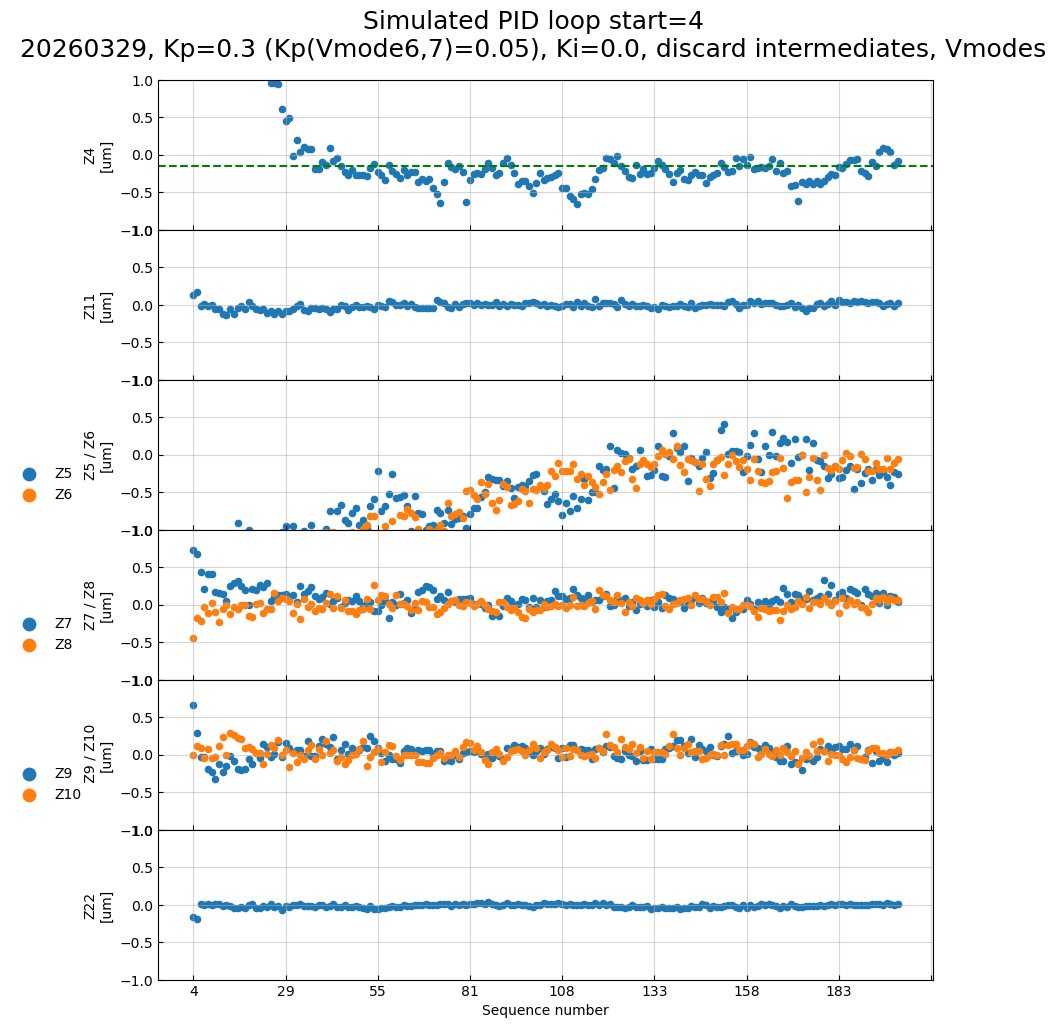

In [75]:
plot_PID(new_zernikes, f"{day_obs}, Kp=0.3 (Kp(Vmode6,7)=0.05), Ki=0.0, discard intermediates, Vmodes",
        f"PID_Simulator_B3_{day_obs}")#, plot_measured=True, z_measured=z_measured)

## Plot the behavior of the integral term

In [ ]:
fig, axs = plt.subplots(2,1,figsize=(15,10))
plt.subplots_adjust(hspace=0)
axs[0].plot(these_seqs, integrals[:,0], marker='x')
axs[1].plot(these_seqs, integrals[:,5], marker='x')